## Transformer Types

Encoder-only: reads the whole input at once and builds contextual representations using bidirectional attention. Good for understanding tasks like classification, tagging, and search. (aka: understand text)

**Decoder-only: reads tokens left-to-right with a causal mask, so each token sees only earlier tokens. Good for generation tasks like next-word prediction and chat. (aka: generate text)** 

Encoder-decoder: the encoder first understands the input, then the decoder generates output token by token while attending to the encoder output. Good for input-to-output tasks like translation and summarization. (aka: transform one text into another)

# 5. Forward and Backward in a Decoder-Only Transformer

This notebook demonstrates that a decoder-only transformer is still a neural network, so it supports both a `forward()` pass and a `backward()` pass during training.

We will build each class separately for learning purposes and then run a tiny training example.

In [2]:
# importing necessary Python libraries
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ImportError:
    plt = None
    HAS_MATPLOTLIB = False

# defining manual_seed to ensure reproducability in 'randomness'
#   any seed number will work as well. 
#   '42' does not bring any special or advantages but it weell known to be used
torch.manual_seed(42)

## Step 1: Token and Positional Embedding

A decoder-only transformer first converts token ids into vectors. We also add positional embeddings so the model knows the order of tokens in the sequence.

In [3]:
# Defining Word Embedding class
#   to process token representation (token + position)
class TokenAndPositionEmbedding(nn.Module):
    # initializing..
    # taking argument
    #   vocab_size: how much unique words represented in token (for vectorized token)
    #   d_model: dimension model (how many numbers inside per token)
    #   max_seq_len: define the maximum number position of seq_len
    def __init__(self, vocab_size, d_model, max_seq_len):
        # inhering the functions and properties from Python NN libraries
        super().__init__()
        # initializing vectorized token and position embedding
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(max_seq_len, d_model)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        batch_size, seq_len = x.shape

        # Create position ids like [0, 1, 2, ..., seq_len-1]
        #   and store as the same location as x
        positions = torch.arange(seq_len, device=x.device)

        # Convert token ids and positions into dense vectors
        token_vectors = self.token_embedding(x)
        position_vectors = self.position_embedding(positions)

        # Broadcasting merge/adds position information to every sequence in the batch
        #   pass the combined token_vectors + position_vectors into next tasks..
        return token_vectors + position_vectors

## Step 2: Causal Multi-Head Attention

This layer lets each token attend only to itself and previous tokens, but now it does so through multiple attention heads.

Each head can learn a different relationship pattern, and then the heads are combined back together. The causal mask still makes the transformer decoder-only.

In [4]:
# Defining Causal Multi-Head Attention (Attention + mask) class
#   to proces vectorized token to talk with one another with vector space (Q,K,V)
#   within multiple focus (heads) and 
#   combine back together in vector space (O)
class CausalMultiHeadAttention(nn.Module):
    # initializing
    def __init__(self, d_model, num_heads):
        # inheriting Python Pytorch NN libraries
        super().__init__()
        assert d_model % num_heads == 0, 'd_model must be divisible by num_heads'

        self.d_model = d_model
        self.num_heads = num_heads
        # use floor division operation (//) to get rounded number of head_dim 
        #   (aka d_k)
        self.head_dim = d_model // num_heads

        # initialize linear projection space for vectorized token to talk one another
        #   for Q, K, V and O
        #   with dimension (d_model, d_model) 
        self.query = nn.Linear(d_model, d_model)
        self.key = nn.Linear(d_model, d_model)
        self.value = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, d_model)

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        batch_size, seq_len, d_model = x.shape

        # Project the input into query, key, and value tensors
        #   into Q, K, V vector space
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        # Split the model dimension into multiple heads
        #   and transpose the dimension between (dim1 and dim2)
        q = q.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        # Vectorized token talks one another takes place..
        # Compute raw attention scores independently for each head (QK^T/ sqrt(head_dim))
        scores = q @ k.transpose(-2, -1) / math.sqrt(self.head_dim)

        # Causal mask blocks access to future tokens
        #   create torch with (seq_len, seq_len) dimension
        #   fills with ones with lower triangle (same as fill one with higher triangle with offset = 1)
        #   change value 0 -> '-inf' (same as value 0 -> '-inf')
        mask = torch.tril(torch.ones(seq_len, seq_len, device=x.device))
        scores = scores.masked_fill(mask == 0, float('-inf'))

        # Softmax turns scores into masked attention weights for each head
        #   softmax() = masked_attention_score -> attention_weight
        #      dim=-1 refers to the innermost dimension (dim_head)
        attention_weights = F.softmax(scores, dim=-1)

        # Weighted sum of value vectors produces context-aware representations per head (QK^T/sqrt(dim_head))V
        #   weighted_sum = attention_weight @ v 
        #   (similar to formula: weighted_sum = wn.in + b in NN)
        attended = attention_weights @ v

        # Merge all heads back into one d_model-sized representation
        # Reshape from (batch_size, seq_len, num_heads, head_dim) ->
        #               (batch_size, seq_len, d_model)
        attended = attended.transpose(1, 2).contiguous().view(batch_size, seq_len, d_model)

        # execute merged/combined masked multi-head attention vectorized from Q,K and V
        #   into linear projection space
        #   and pass into next tasks..
        return self.out(attended)

## Step 3: Feed-Forward Network

After attention, each token representation goes through a small neural network. This helps the model transform features at each position independently.

In [5]:
# Defining Feed Forward Network class
#   to proces the updated individual vectorized tokens
#   into feedForward neural network to
#   process transform the updated vectorized tokens based on given context    
class FeedForward(nn.Module):
    # initializing..
    def __init__(self, d_model, d_ff):
        # inheriting Python PyTorch NN libraries
        super().__init__()

        # create one var as runs in sequence
        #   linear() projection space as linear1
        #   run through activation function
        #   linear() proejction space as linear2
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            # the dimension initialized as transposed for matmul()
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        # This is the position-wise MLP used after attention
        #   This is similar like MLP in NN
        return self.net(x)

## Step 4: Decoder Block

A decoder block combines causal multi-head attention, dropout, a feed-forward network, residual connections, and layer normalization.

The dropout layer randomly removes some activations during training, which helps reduce overfitting and makes the model more robust.

In [6]:
# Defining DecoderBlock class
#   integrate causalmultiheadattention(), feedforward()
#   with addition of:
#       - dropout (regularization and ensuring generalization, avoid overfitting)
#       - residual connection (adds back x original information)
#       - normalization (ensuring stable training)
class DecoderBlock(nn.Module):
    # initializing
    def __init__(self, d_model, d_ff, num_heads, dropout=0.1):
        # inheriting the Python PyTorch NN libraries
        super().__init__()

        # utilize the created classes above
        # causalmultiheadattention object
        self.attention = CausalMultiHeadAttention(d_model, num_heads)
        # dropout addition object after causalmultiheadattention()
        self.dropout1 = nn.Dropout(dropout)
        # normalize ensuring hidden feature representations is stable for next task..
        self.norm1 = nn.LayerNorm(d_model)

        # feedforward object
        self.feed_forward = FeedForward(d_model, d_ff)
        # dropout addition object after feedforward()
        self.dropout2 = nn.Dropout(dropout)
        # normalize ensuring hidden feature representation is stable for next task..
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        # Dropout regularizes the attention output before the residual add
        #   process causal multi head attention from (x input)
        #     -> dropout from updated vectorized tokens
        #     -> added back original information of x input (residual)
        #     -> normalize for stable training..
        x = self.norm1(x + self.dropout1(self.attention(x)))

        # new-x in this task (feedforward): 
        #   x after processed 
        #       - multi head attention
        #       - dropout
        #       - added residual
        #       - normalization 

        # Dropout also regularizes the feed-forward output
        #   process causal multi head attention from (new-x input)
        #     -> dropout from transformed updated vectorized tokens
        #     -> added back original information of new-x input (residual)
        #     -> normalize for stable training..
        x = self.norm2(x + self.dropout2(self.feed_forward(x)))
        return x

## Step 5: Complete Decoder-Only Transformer

Now we combine embeddings, multiple decoder blocks, a final layer normalization, and a final linear layer that maps hidden states to vocabulary logits.

Using several decoder blocks makes the model a bit closer to a real transformer, because the hidden representation is refined multiple times before producing logits.

In [7]:
# Defining DecoderOnlyTransformer class
#   integrate embedding(), multiple DecoderBlock() layers
#   with addition of:
#       - final layer normalization before logits
#       - output layer (final linear layer mapss hidden states to vocabulary logits)
class DecoderOnlyTransformer(nn.Module):
    # initializing..
    def __init__(self, vocab_size, d_model, max_seq_len, d_ff, num_heads, num_layers, dropout=0.1):
        # inheriting Python PyTorch NN libraries
        super().__init__()

        # creating objects from created classes above..
        # create embedding class
        self.embedding = TokenAndPositionEmbedding(vocab_size, d_model, max_seq_len)
        # create multiple DecoderBlock layers to refine token representations step by step
        self.decoder_blocks = nn.ModuleList([
            DecoderBlock(d_model, d_ff, num_heads, dropout=dropout)
            for _ in range(num_layers)
        ])
        # create final normalization layer before the logits projection
        self.final_norm = nn.LayerNorm(d_model)
        # create final layer linear porjection space
        #   to represent back from d_model into vocab_size
        self.output_layer = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        # 1. Convert token ids into embeddings
        #   x input -> x's vectorized tokens (token + position)
        x = self.embedding(x)

        # 2. Pass embeddings through each decoder block
        #   each block refines the token representation again
        #   x's vectorized tokens (token + position) -> x's transformed updated vectorized token
        #       through hidden layers and states
        for decoder_block in self.decoder_blocks:
            x = decoder_block(x)

        # 3. Normalize the final hidden representation before projection
        x = self.final_norm(x)

        # 4. Convert hidden states into logits (prediction_score) for every token position
        #   x's transormed updated vectorized token -> logits (prediction_score) of each word
        logits = self.output_layer(x)
        return logits

## Step 6: Prepare a Tiny Next-Token Prediction Example

We will train the model on a tiny batch. The input sequence is the context, and the target sequence is the next-token label for each position.

In [ ]:
# Set the definition of parameters
vocab_size = 20
d_model = 16
d_ff = 32
num_heads = 4
num_layers = 3
dropout = 0.1
max_seq_len = 6

# initialize the combined DecoderOnlyTransformer
model = DecoderOnlyTransformer(
    vocab_size=vocab_size,
    d_model=d_model,
    max_seq_len=max_seq_len,
    d_ff=d_ff,
    num_heads=num_heads,
    num_layers=num_layers,
    dropout=dropout,
)

# define the input
inputs = torch.tensor([
    [1, 2, 3, 4, 5, 6],
    [2, 3, 4, 5, 6, 7]
], dtype=torch.long)

# define the actual output target (ground-truth)
targets = torch.tensor([
    [2, 3, 4, 5, 6, 7],
    [3, 4, 5, 6, 7, 8]
], dtype=torch.long)

# printing out the dimension between input and target (both should be same)
inputs.shape, targets.shape

(torch.Size([2, 6]), torch.Size([2, 6]))

## Step 7: Forward Pass

Calling `model(inputs)` triggers the `forward()` methods of all the classes above. The output is a tensor of logits with shape `(batch_size, seq_len, vocab_size)`.

In [ ]:
logits = model(inputs) # <-- also calls model.forward()
print('Logits shape:', logits.shape)
# shows the elements in logits in dimension (batch_size, seq_len, vocab_size)
#   [0, 0, :5] 
#       - take the first item batch
#       - take first token position
#       - take the frist 5 values in vocabulary scores (0 <= logits < 5)
logits[0, 0, :5]

Logits shape: torch.Size([2, 6, 20])


tensor([-0.1810, -1.1157,  0.7747, -0.8839, -1.2445], grad_fn=<SliceBackward0>)

## Step 8: Compute Loss

The model output alone is not enough for training. We compare the logits against the target tokens using cross-entropy loss.

In [ ]:
# CrossEntropyLoss expects shape (N, C), so we flatten batch and sequence together.
#   N = number of training examples
#   C = number of classes
    # flatten from (batch_size, seq_len) into (batch_size * seq_len) 
loss = F.cross_entropy(
    # Reshape the (batch_size, seq_len, vocab_size) -> (batch_size * seq_len, vocab_size)
    logits.view(-1, vocab_size),
    # Reshape the (batch_size, seq_len) -> (batch_size * seq_len)
    targets.view(-1)
)

# shows out loss.item() that contains
#   sclar numeric of loss (rate of changes needed between predicted and target)
print('Loss:', loss.item())

Loss: 3.3263328075408936


## Step 9: Backward Pass

This is the key idea: even though we built a decoder-only transformer, training still uses backpropagation like any other neural network.

Calling `loss.backward()` computes gradients for all learnable parameters.

In [ ]:
# reset any stored gradient history..
model.zero_grad()

# Computes gradient for all learnable parameters..
#   Calculate new gradients/slope (weight) based on current loss
#   Similar to backward() in NN
loss.backward()

# These gradients were created by autograd during backpropagation.
print('Gradient shape for output layer weight:', model.output_layer.weight.grad.shape)
print('Gradient sample from output layer weight:')
print(model.output_layer.weight.grad[:2, :5])

Gradient shape for output layer weight: torch.Size([20, 16])
Gradient sample from output layer weight:
tensor([[-0.0226, -0.0301,  0.0257,  0.0136,  0.0050],
        [-0.0456, -0.0242,  0.0376, -0.0034,  0.0065]])


## Step 10: One Parameter Update

After `backward()`, an optimizer uses the gradients to update the weights. This is one training step, and repeating this process across many epochs is how the model learns.

In [ ]:
# initialize optimizer by using Adam's optimizer
#   and define learning_rate = 0.01
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Use the new gradients/slope (weight) and update into NN
optimizer.step()

print('One optimization step completed.')

One optimization step completed.


## Step 11: Train for Multiple Epochs

To see a learning curve, we train for many epochs and store the loss after each epoch. If the model is learning the pattern, the loss should go down over time.

In [ ]:
# Re-create a fresh model so we can observe learning from the beginning
model = DecoderOnlyTransformer(
    vocab_size=vocab_size,
    d_model=d_model,
    max_seq_len=max_seq_len,
    d_ff=d_ff,
    num_heads=num_heads,
    num_layers=num_layers,
    dropout=dropout,
)

# re-create optimizer object
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# create num_epochs and loss_history to store loss
num_epochs = 100
loss_history = []

# set the model of DecoderOnlyTransformer into training mode..
#   training mode enables:
#       - dropout
#           - activations are randomly dropped during training
#           - helps regularization and generalizability
#           - avoids overfitting
model.train()

# running the training learn in loops based on number of epochs
for epoch in range(num_epochs):
    # reset any stored gradients
    optimizer.zero_grad()

    # Forward pass for the whole batch
    logits = model(inputs)

    # Flatten token predictions so cross entropy can compare each token position
    loss = F.cross_entropy(
        logits.view(-1, vocab_size),
        targets.view(-1)
    )

    # Backward pass computes gradients for every learnable parameter
    loss.backward()

    # Optimizer updates the weights using those gradients
    optimizer.step()

    # store the history of number of loss 
    #   (rate of change or correctness needed between predicted against target (ground-truth)) 
    loss_history.append(loss.item())

    # show the progress of loss after 20 epochs
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch + 1:3d}/{num_epochs} | Loss: {loss.item():.4f}')

print('Training complete.')
# demonstrate the loss in the first 5 epochs and round up into 4 decimal places
print('First 5 losses:', [round(x, 4) for x in loss_history[:5]])
# demonstrate the loss in the last 5 epochs and round up into 4 decimal places
print('Last 5 losses:', [round(x, 4) for x in loss_history[-5:]])

Epoch  20/100 | Loss: 0.1720
Epoch  40/100 | Loss: 0.0191
Epoch  60/100 | Loss: 0.0072
Epoch  80/100 | Loss: 0.0051
Epoch 100/100 | Loss: 0.0033
Training complete.
First 5 losses: [3.007, 2.2925, 1.9065, 1.6607, 1.485]
Last 5 losses: [0.0034, 0.0036, 0.0037, 0.0035, 0.0033]


## Step 12: Visualize the Learning Curve

This plot shows how the loss changes across epochs. A downward trend means the decoder-only transformer is learning the next-token pattern in this toy dataset.

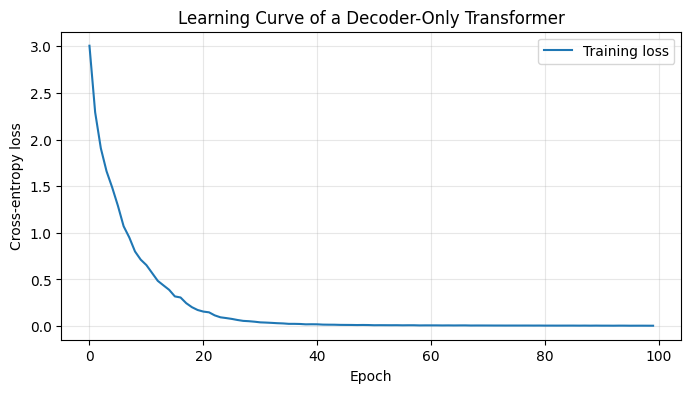

In [17]:
# This cell is self-contained, so it still works even if you run it before the import cell above.
try:
    import matplotlib.pyplot as plt
    has_matplotlib = True
except ImportError:
    plt = None
    has_matplotlib = False

if has_matplotlib:
    plt.figure(figsize=(8, 4))
    plt.plot(loss_history, label='Training loss')
    plt.xlabel('Epoch')
    plt.ylabel('Cross-entropy loss')
    plt.title('Learning Curve of a Decoder-Only Transformer')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    print('matplotlib is not installed, so only the numeric loss history is shown.')

## Step 13: Simple Inference

After training, we can switch the model to evaluation mode and generate tokens. Here we use greedy decoding, which means we always choose the token with the highest predicted logit.

In [ ]:
# Definining greed_generate function
#   set the model into evaluation mode
#   test the model to generate..
# Greedy decoding are chosen to choose the token with highest predicted logit
def greedy_generate(model, start_tokens, max_new_tokens):
    # change the model into evaluation mode..
    #   evaluation mode disables (even the code exists):
    #       - dropout
    model.eval()

    # clone the start_tokens into generate for model for input
    generated = start_tokens.clone()

    # torch.no_grad() means do not track operations for gradient computation
    #   saves memory and speed up inferencing as gradient computation tracking needed in training
    with torch.no_grad():
        # repeat in loop untill reach max_new_tokens
        #   (generate how much new_tokens)
        for _ in range(max_new_tokens):
            # Keep only the last max_seq_len tokens so positional embeddings stay valid
            input_window = generated[:, -max_seq_len:]

            # runs forward()
            logits = model(input_window)

            # Use the last token position to predict the next token
            #   logits dimension (batch_size, seq_len, vocab_size)
            #   Therefore, it takes the very last position (seq_len)
            #       - As autoregressive nature, use the current sequence
            #       - model predicts logits for every position
            #       - last position is used to decide the next token to append
            next_token_logits = logits[:, -1, :]

            # next_token assigned through greedy_decoding by
            #   argmax() look across innermost (dim=-1) dimension (vocabulary dimension - vocab_size)            #   find  the highest logit score
            #   return the token_id
            #   keepdim=True means keep output as column shape (keep as (batch_size, seq_len, vocab_size))
            next_token = torch.argmax(next_token_logits, dim=-1, keepdim=True)

            # append/concatenate the next_token into generated in dim=1 
            generated = torch.cat([generated, next_token], dim=1)

    return generated

# Start from a short prompt and let the model continue the learned pattern
start_tokens = torch.tensor([[1, 2, 3]], dtype=torch.long)
generated_sequence = greedy_generate(model, start_tokens, max_new_tokens=5)

# listing the start_tokens as input
print('Start tokens:', start_tokens.tolist())
# listing the genereated_sequence: start_tokens + new_token(s) untill max_new_token
print('Generated sequence:', generated_sequence.tolist())

Start tokens: [[1, 2, 3]]
Generated sequence: [[1, 2, 3, 4, 5, 6, 7, 8]]


## Summary

- `forward()` moves data through embeddings, attention, feed-forward layers, and the output layer.
- `loss.backward()` sends gradients backward through the whole decoder-only transformer.
- Repeating forward, loss, backward, and optimizer updates across epochs produces a learning curve.
- After training, the model can run inference by generating the next token from the learned pattern.